In [1]:
import pickle
import os
from sklearn.decomposition import PCA

In [12]:
dataset = "fashion"

In [13]:
llm_item_emb = pickle.load(open(os.path.join(dataset+"/handled/", "itm_emb_np.pkl"), "rb"))

In [3]:
llm_user_emb = pickle.load(open(os.path.join(dataset+"/handled/", "usr_emb_np_qwen_mean.pkl"), "rb"))

In [14]:
llm_item_emb.shape

(4722, 1536)

In [5]:
pca = PCA(n_components=64)
pca_item_emb = pca.fit_transform(llm_item_emb)

In [6]:
with open(os.path.join(dataset+"/handled/", "pca64_itm_emb_np.pkl"), "wb") as f:
    pickle.dump(pca_item_emb, f)

In [15]:
pca = PCA(n_components=128)
pca_item_emb = pca.fit_transform(llm_item_emb)

In [16]:
with open(os.path.join(dataset+"/handled/", "pca128_itm_emb_np.pkl"), "wb") as f:
    pickle.dump(pca_item_emb, f)

In [6]:
id_item_emb = pickle.load(open(os.path.join(dataset+"/handled/", "itm_emb_np.pkl"), "rb"))

In [6]:
mode = "doubao"

In [4]:
llm_user_emb = pickle.load(open(os.path.join(dataset+"/handled/", f"usr_emb_np_doubao.pkl"), "rb"))

In [5]:
pca = PCA(n_components=128)
pca_user_emb = pca.fit_transform(llm_user_emb)

In [7]:
with open(os.path.join(dataset+"/handled/", f"pca128_user_emb_np_{mode}.pkl"), "wb") as f:
    pickle.dump(pca_user_emb, f)

In [53]:
# =========================
# step1: 降维并保存
# =========================
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pickle
import torch
import random

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

# 用户向量
user_embeddings_euie = pickle.load(open(dataset+"/handled/usr_emb_np_qwen_mean.pkl", "rb"))
user_embeddings_orig = pickle.load(open(dataset+"/handled/usr_emb_np.pkl", "rb"))

def reduce_tsne(embeddings, seed=SEED):
    pca = PCA(n_components=50, random_state=seed)
    reduced = pca.fit_transform(embeddings)
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        n_iter=2000,
        learning_rate=300,
        init='pca',
        random_state=42
    )
    return tsne.fit_transform(reduced)

# 降维
reduced_euie = reduce_tsne(user_embeddings_euie)
reduced_orig = reduce_tsne(user_embeddings_orig)

# 保存结果
with open(dataset+"/handled/reduced_euie.pkl", "wb") as f:
    pickle.dump(reduced_euie, f)
with open(dataset+"/handled/reduced_orig.pkl", "wb") as f:
    pickle.dump(reduced_orig, f)


In [20]:
from collections import defaultdict
User = defaultdict(list)
seq_len = []
usernum, itemnum = 0, 0
f = open('./%s/handled/%s.txt' % (dataset, "inter"), 'r')
for line in f:  # use a dict to save all seqeuces of each user
    u, i = line.rstrip().split(' ')
    u = int(u)
    i = int(i)
    usernum = max(u, usernum)
    itemnum = max(i, itemnum)
    User[u].append(i)

for user, seq in User.items():
    seq_len.append(len(seq))

/tmp/ipykernel_37677/340122049.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # 留出右侧颜色条空间


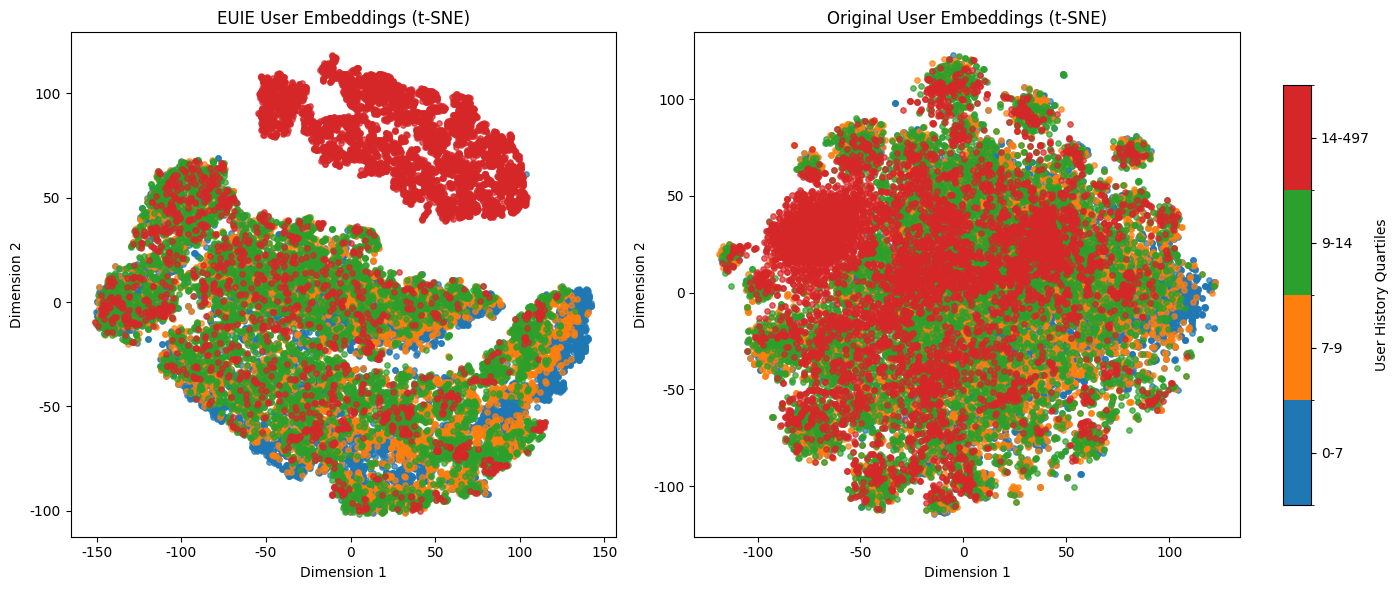

In [55]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

user_history_counts = np.array(seq_len)

# 四分位划分
q25, q50, q75 = np.percentile(user_history_counts, [25, 50, 75])
bins = [user_history_counts.min()-1, q25, q50, q75, user_history_counts.max()+1]
labels_prior = np.digitize(user_history_counts, bins) - 1
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
cmap = ListedColormap(colors)
norm = BoundaryNorm(bins, cmap.N)

# 绘图
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i in range(4):
    axes[0].scatter(reduced_euie[labels_prior==i,0], reduced_euie[labels_prior==i,1],
                    s=15, alpha=0.7, color=colors[i], label=f'Q{i+1}')
axes[0].set_title("EUIE User Embeddings (t-SNE)")
axes[0].set_xlabel("Dimension 1")
axes[0].set_ylabel("Dimension 2")

for i in range(4):
    axes[1].scatter(reduced_orig[labels_prior==i,0], reduced_orig[labels_prior==i,1],
                    s=15, alpha=0.7, color=colors[i], label=f'Q{i+1}')
axes[1].set_title("Original User Embeddings (t-SNE)")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")

# 统一颜色条，放在右侧
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, boundaries=bins)
# tick 放在每个区间中间
tick_positions = [(bins[i]+bins[i+1])/2 for i in range(len(bins)-1)]
tick_labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]
cbar.set_ticks(tick_positions)
cbar.set_ticklabels(tick_labels)
cbar.set_label("User History Quartiles")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # 留出右侧颜色条空间
plt.show()


/tmp/ipykernel_37677/1179530663.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # 留出右侧颜色条空间


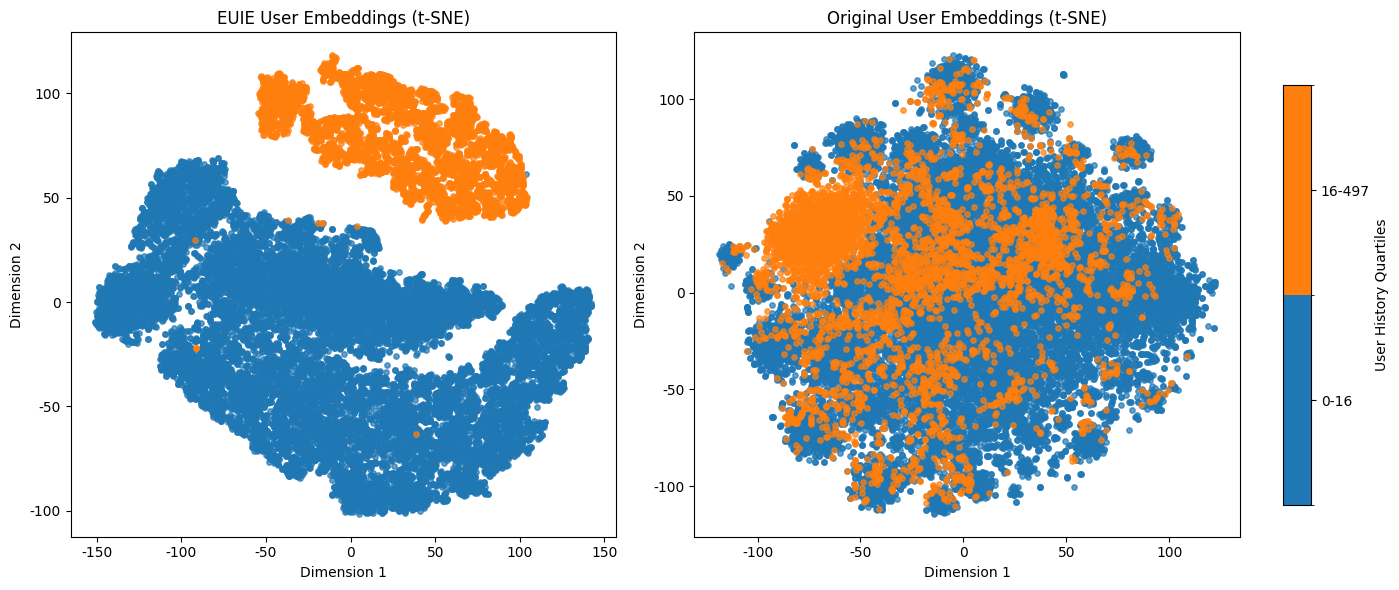

In [59]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

user_history_counts = np.array(seq_len)

# 四分位划分
q25 = 16
bins = [user_history_counts.min()-1, q25, user_history_counts.max()+1]
labels_prior = np.digitize(user_history_counts, bins) - 1
colors = ['#1f77b4', '#ff7f0e']
cmap = ListedColormap(colors)
norm = BoundaryNorm(bins, cmap.N)

# 绘图
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i in range(2):
    axes[0].scatter(reduced_euie[labels_prior==i,0], reduced_euie[labels_prior==i,1],
                    s=15, alpha=0.7, color=colors[i], label=f'Q{i+1}')
axes[0].set_title("EUIE User Embeddings (t-SNE)")
axes[0].set_xlabel("Dimension 1")
axes[0].set_ylabel("Dimension 2")

for i in range(2):
    axes[1].scatter(reduced_orig[labels_prior==i,0], reduced_orig[labels_prior==i,1],
                    s=15, alpha=0.7, color=colors[i], label=f'Q{i+1}')
axes[1].set_title("Original User Embeddings (t-SNE)")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")

# 统一颜色条，放在右侧
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, boundaries=bins)
# tick 放在每个区间中间
tick_positions = [(bins[i]+bins[i+1])/2 for i in range(len(bins)-1)]
tick_labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]
cbar.set_ticks(tick_positions)
cbar.set_ticklabels(tick_labels)
cbar.set_label("User History Quartiles")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # 留出右侧颜色条空间
plt.show()
